In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 制作统计图形的数据可视化库
import seaborn as sns
from datetime import datetime, timedelta


In [83]:
# 解决显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [84]:
df_trade = pd.read_csv('tianchi_mum_baby_trade_history.csv')

df_baby = pd.read_csv('tianchi_mum_baby.csv')

In [85]:
df_baby.head()

,user_id,birthday,gender
0,2757,20130311,1
1,415971,20121111,0
2,1372572,20120130,1
3,10339332,20110910,0
4,10642245,20130213,0


In [86]:
df_trade.head()

,user_id,auction_id,category_2,category_1,buy_mount,day
0,786295544,41098319944,50014866,50022520,2,20140919
1,532110457,17916191097,50011993,28,1,20131011
2,249013725,21896936223,50012461,50014815,1,20131011
3,917056007,12515996043,50018831,50014815,2,20141023
4,444069173,20487688075,50013636,50008168,1,20141103


In [87]:
df_trade.dtypes

user_id       int64
auction_id    int64
category_2    int64
category_1    int64
buy_mount     int64
day           int64
dtype: object

In [88]:
df_trade['day'] = pd.to_datetime(df_trade.day.astype('str'))
df_trade.head()

,user_id,auction_id,category_2,category_1,buy_mount,day
0,786295544,41098319944,50014866,50022520,2,2014-09-19
1,532110457,17916191097,50011993,28,1,2013-10-11
2,249013725,21896936223,50012461,50014815,1,2013-10-11
3,917056007,12515996043,50018831,50014815,2,2014-10-23
4,444069173,20487688075,50013636,50008168,1,2014-11-03


In [89]:
df_trade['year'] = df_trade.day.dt.year
df_trade['quarter'] = df_trade.day.dt.quarter
df_trade['month'] = df_trade.day.dt.month
df_trade.head()

,user_id,auction_id,category_2,category_1,buy_mount,day,year,quarter,month
0,786295544,41098319944,50014866,50022520,2,2014-09-19,2014,3,9
1,532110457,17916191097,50011993,28,1,2013-10-11,2013,4,10
2,249013725,21896936223,50012461,50014815,1,2013-10-11,2013,4,10
3,917056007,12515996043,50018831,50014815,2,2014-10-23,2014,4,10
4,444069173,20487688075,50013636,50008168,1,2014-11-03,2014,4,11


In [90]:
df_trade.day.describe()

count                            29971
mean     2014-01-16 17:25:38.086817536
min                2012-07-02 00:00:00
25%                2013-06-20 00:00:00
50%                2014-03-06 00:00:00
75%                2014-09-09 00:00:00
max                2015-02-05 00:00:00
Name: day, dtype: object

In [91]:
df_trade.buy_mount.describe()

count    29971.000000
mean         2.544126
std         63.986879
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      10000.000000
Name: buy_mount, dtype: float64

In [92]:
df_trade = df_trade[(df_trade.buy_mount >= 1) & (df_trade.buy_mount <= 189)]
df_trade.buy_mount.describe()

count    29940.000000
mean         1.656179
std          5.026888
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        176.000000
Name: buy_mount, dtype: float64

In [93]:
# nunique()：统计不重复值；sum()求和
count_user = df_trade['user_id'].nunique()
count_auction = df_trade['auction_id'].nunique()
count_category_1 = df_trade['category_1'].nunique()
count_category_2 = df_trade['category_2'].nunique()
count_buy_mount = df_trade['buy_mount'].sum()

print(f"用户数：{count_user}")
print(f"交易数：{count_auction}")
print(f"商品一级类目数：{count_category_1}")
print(f"商品二级类目数：{count_category_2}")
print(f"总销量：{count_buy_mount}")


用户数：29913
交易数：28392
商品一级类目数：6
商品二级类目数：662
总销量：49586


In [94]:
df_baby.count()

user_id     953
birthday    953
gender      953
dtype: int64

In [95]:
# 只保留性别0、1
df_baby = df_baby[df_baby['gender'].isin([0,1])]

# 查看清洗后分布
print(df_baby['gender'].value_counts())

# 将数字映射为中文，方便后续绘图分析
df_baby['gender'] = df_baby['gender'].map({0:"女",1:"男"})
print(df_baby['gender'].value_counts())


gender
0    489
1    438
Name: count, dtype: int64
gender
女    489
男    438
Name: count, dtype: int64


In [96]:
df_baby

,user_id,birthday,gender
0,2757,20130311,男
1,415971,20121111,女
2,1372572,20120130,男
3,10339332,20110910,女
4,10642245,20130213,女
...,...,...,...
948,2020957900,20140430,女
949,2080304899,20100713,女
950,2114469016,20140416,女
951,2186831536,20140519,男


In [97]:
df_baby['birthday'] = pd.to_datetime(df_baby.birthday.astype('str'))
df_baby.birthday.describe()


count                              927
mean     2012-03-04 16:37:16.893203712
min                1984-06-16 00:00:00
25%                2011-02-09 12:00:00
50%                2012-08-07 00:00:00
75%                2013-09-26 12:00:00
max                2015-08-15 00:00:00
Name: birthday, dtype: object

In [98]:
df_baby = df_baby[df_baby.birthday > '2010-01-01']
df_baby.birthday.describe()

count                              798
mean     2012-11-01 04:10:49.624060160
min                2010-01-05 00:00:00
25%                2011-10-17 18:00:00
50%                2012-11-25 00:00:00
75%                2013-11-23 06:00:00
max                2015-08-15 00:00:00
Name: birthday, dtype: object

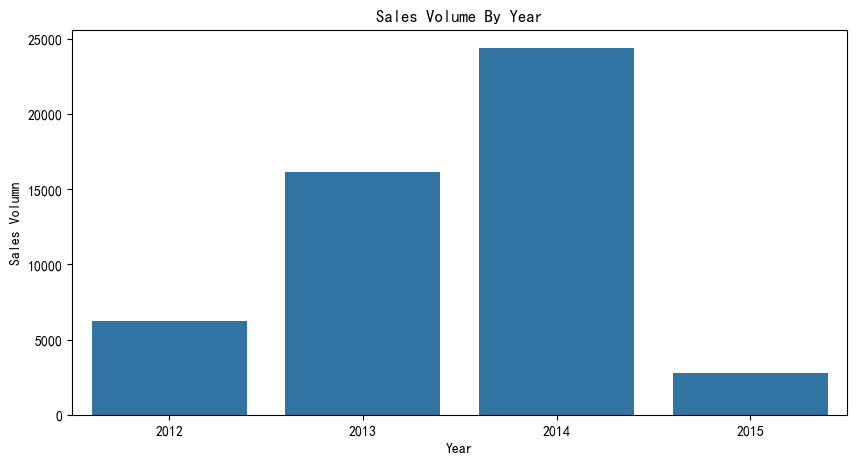

In [99]:
year_stats = df_trade.groupby(by='year')['buy_mount'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=year_stats.index, y=year_stats.values)

plt.title("Sales Volume By Year")
plt.xlabel("Year")
plt.ylabel("Sales Volumn")
plt.show()

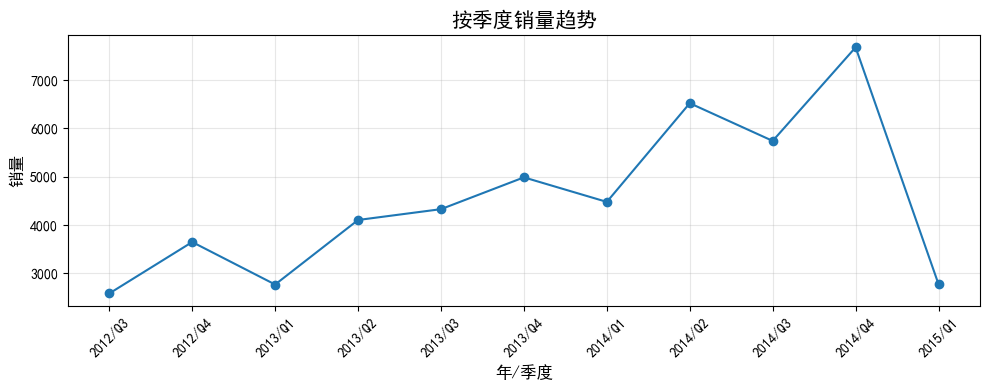

In [100]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
year_quarter_stats = df_trade.groupby(by=['year', 'quarter'])['buy_mount'].sum()


# 你这两行
x_list = [str(idx[0]) + "/Q" + str(idx[1]) for idx in year_quarter_stats.index]
y_list = [int(value) for value in year_quarter_stats.values]

plt.figure(figsize=(10,4))
plt.plot(x_list, y_list, marker='o')

plt.title("按季度销量趋势", fontsize=15)
plt.xlabel("年/季度", fontsize=12)
plt.ylabel("销量", fontsize=12)
plt.xticks(rotation=45) #x轴文字旋转，防止重叠
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


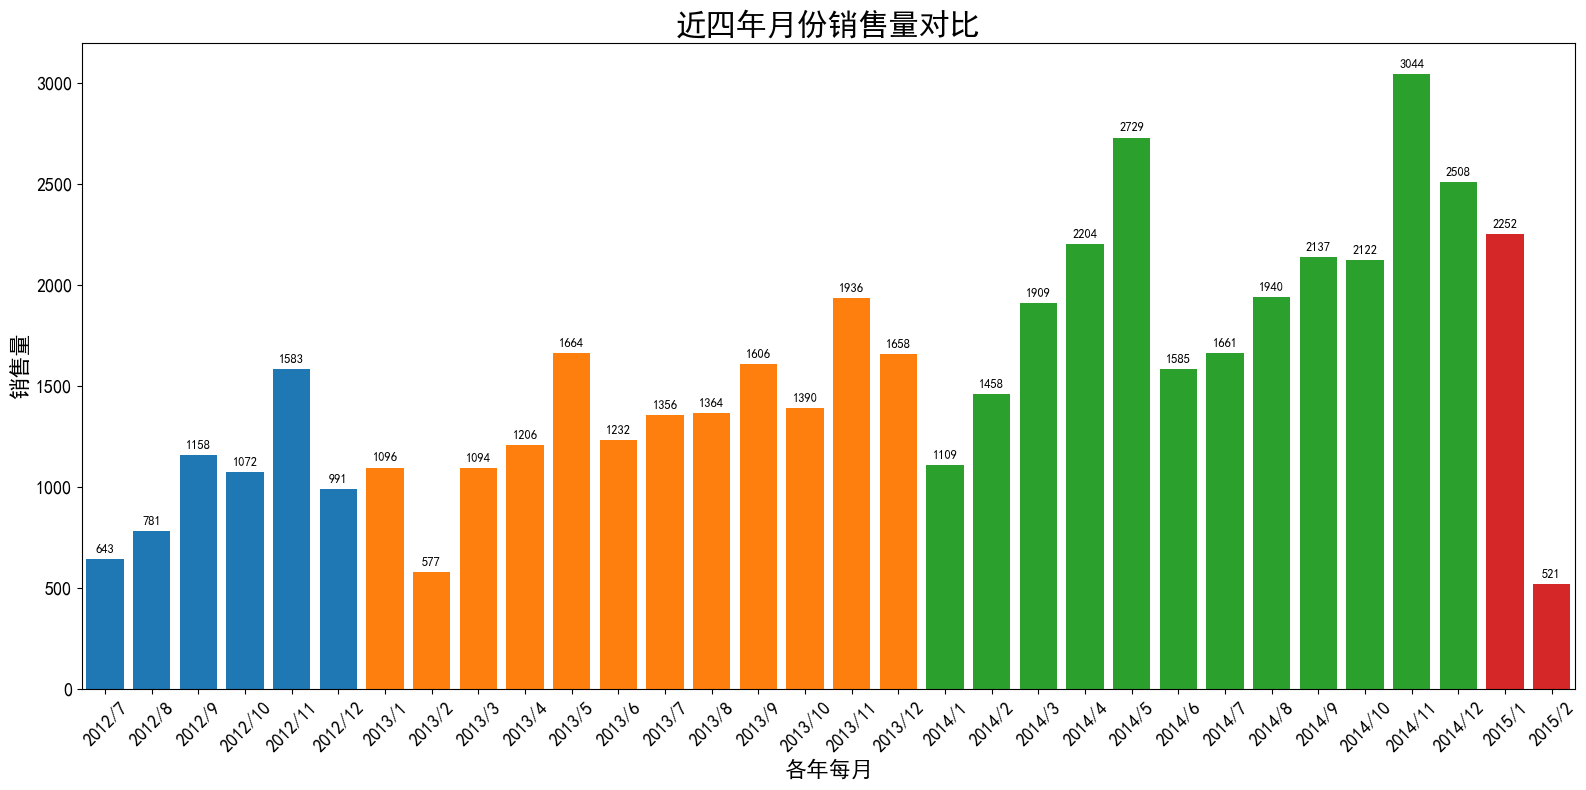

In [101]:
month_stats=df_trade.groupby(by=['year','month'])['buy_mount'].sum()

plt.figure(figsize=(16,8))
x_list=[str(idx[0])+"/"+str(idx[1]) for idx in month_stats.index]
y_list=[int(value) for value in month_stats.values]

ax = sns.barplot(x=x_list,y=y_list)

# 1、按年份设置柱子颜色
year_color = {
    "2012":"#1f77b4",
    "2013":"#ff7f0e",
    "2014":"#2ca02c",
    "2015":"#d62728"
}
for bar, x_text in zip(ax.patches, x_list):
    year_str = x_text.split("/")[0]
    bar.set_facecolor(year_color[year_str])

# 2、在每个柱子上方写上销量数字
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height)}",                #显示整数销量
                xy=(p.get_x()+p.get_width()/2, height),
                xytext=(0,3),                     #数字向上偏移3像素，防止贴住柱子
                textcoords="offset points",
                ha="center", va="bottom", fontsize=9)


plt.title('近四年月份销售量对比',fontsize=22)
plt.xlabel('各年每月',fontsize=16)
plt.ylabel('销售量',fontsize=16)
plt.xticks(rotation=45, fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


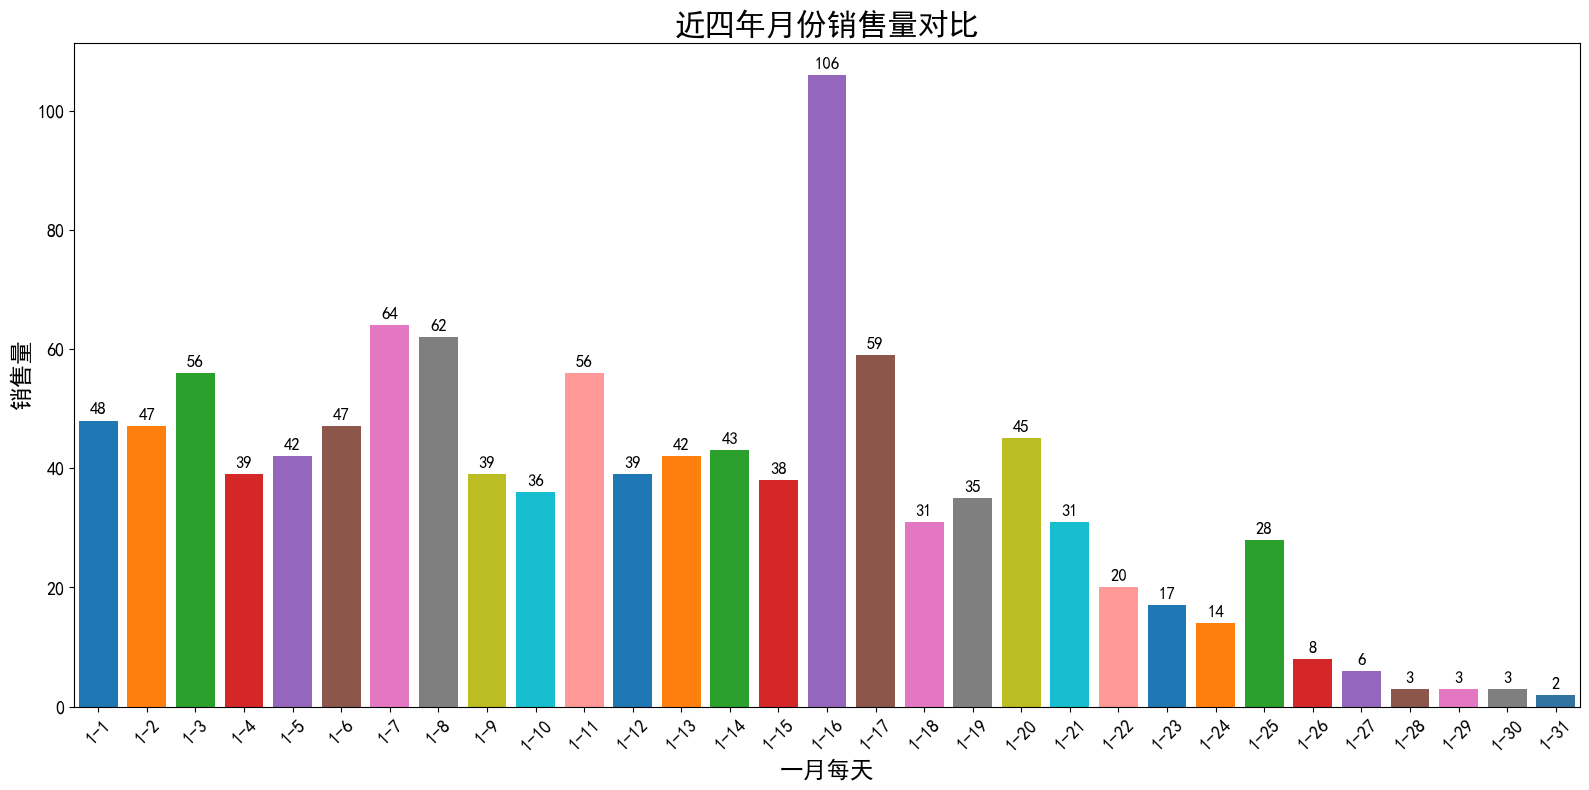

In [102]:
df_trade_201401=df_trade[(df_trade.day >= '2014-01-01') & (df_trade.day < '2014-02-01')]
day_satas=df_trade_201401.groupby(by='day')['buy_mount'].sum()

plt.figure(figsize=(16,8))
x_list=[str(idx.month)+'-'+str(idx.day) for idx in day_satas.index]
y_list=[int(value) for value in day_satas.values]

# ✅1.先定义颜色列表！
color_list = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf','#ff9896',
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf','#ff9896',
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f'
]

# ✅2.去掉color=color_list，不要在这里传颜色！
ax=sns.barplot(x=x_list,y=y_list)

# ✅3.循环给每根柱子上色
for bar,c in zip(ax.patches, color_list):
    bar.set_facecolor(c)

# 柱子顶部写数字
for p in ax.patches:
    height=p.get_height()
    ax.annotate(f"{int(height)}",
                xy=(p.get_x()+p.get_width()/2,height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center',va="bottom",fontsize=12)

plt.title('近四年月份销售量对比',fontsize=22)
plt.xlabel('一月每天',fontsize=17)
plt.ylabel('销售量',fontsize=17)
plt.xticks(rotation=45,fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.savefig('日销售量.png')
plt.show()


## 类目分析

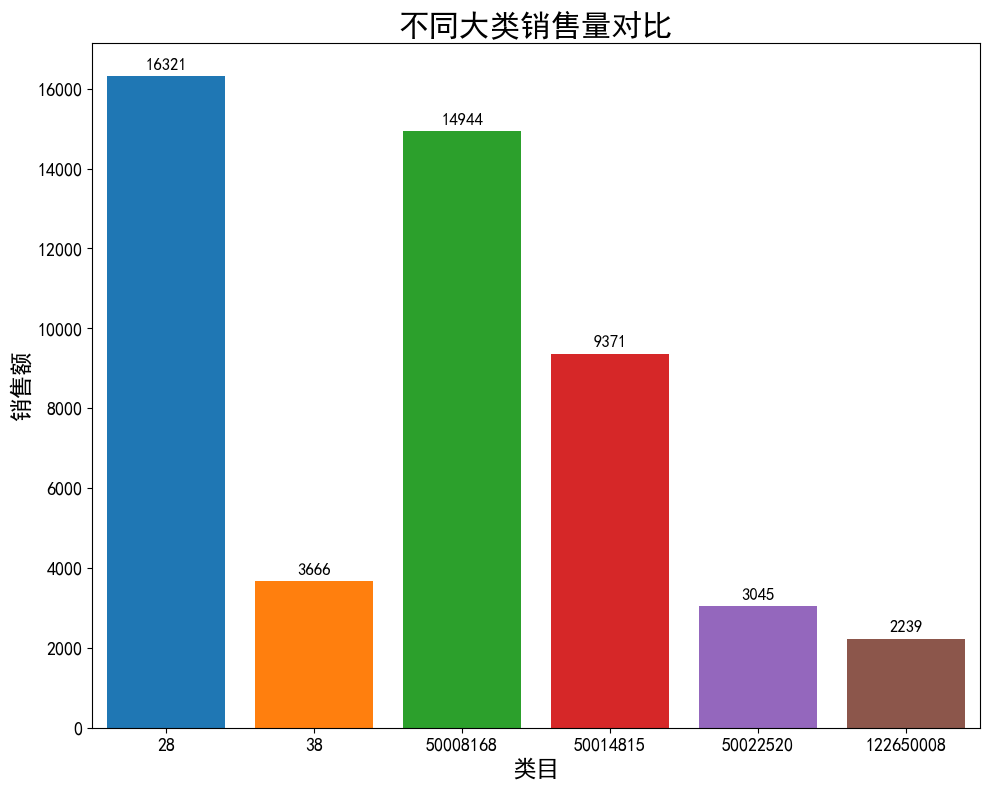

In [103]:
category_1_stats=df_trade.groupby(by="category_1")['buy_mount'].sum()
plt.figure(figsize=(10,8))
color_list = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b'
]
ax=sns.barplot(x=category_1_stats.index,y=category_1_stats.values)
for bar,c in zip(ax.patches,color_list):
    bar.set_facecolor(c)

for p in ax.patches:
    height=p.get_height()
    ax.annotate(f"{int(height)}",
                xy=(p.get_x()+p.get_width()/2,height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center',va='bottom',fontsize=12)
plt.title('不同大类销售量对比',fontsize=22)
plt.xlabel('类目',fontsize=17)
plt.ylabel('销售额',fontsize=17)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


In [104]:
df_trade['category_2'].value_counts()

category_2
50013636     2066
50010558     1340
50013207     1148
50006602      923
50011993      862
             ... 
50024081        1
121404024       1
50003636        1
121380045       1
50026466        1
Name: count, Length: 662, dtype: int64

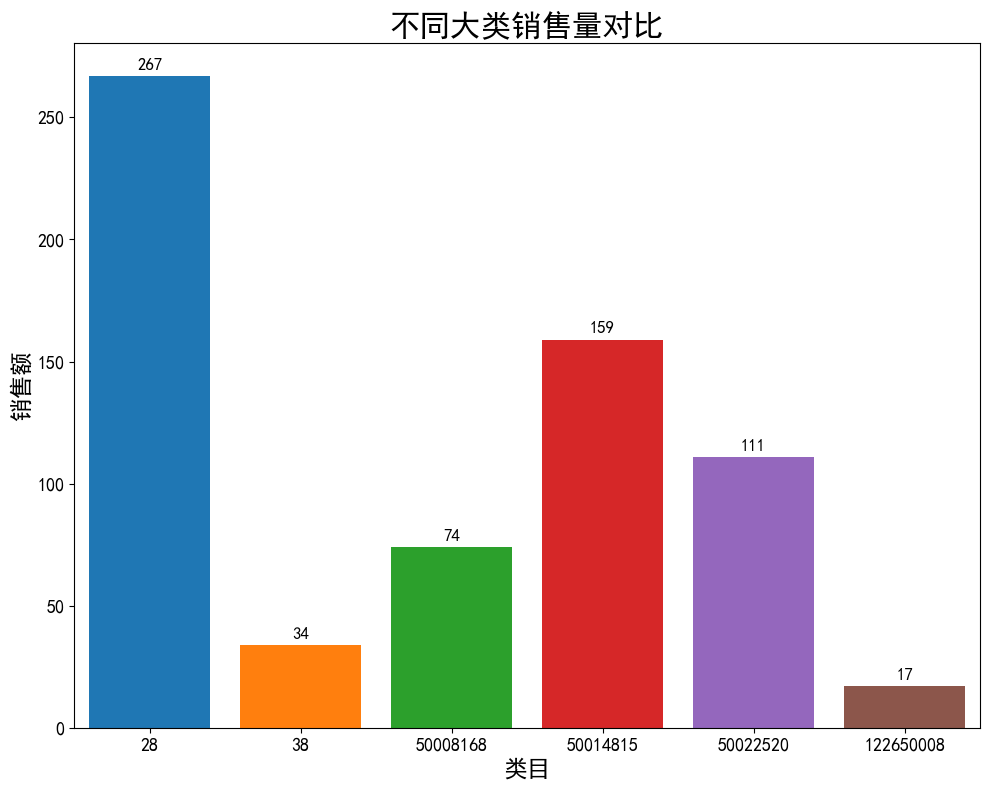

In [105]:
category_2_stats=df_trade.groupby("category_1")['category_2'].nunique()
plt.figure(figsize=(10,8))
color_list = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b'
]
ax=sns.barplot(x=category_2_stats.index,y=category_2_stats.values)
for bar,c in zip(ax.patches,color_list):
    bar.set_facecolor(c)

for p in ax.patches:
    height=p.get_height()
    ax.annotate(f"{int(height)}",
                xy=(p.get_x()+p.get_width()/2,height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center',va='bottom',fontsize=12)
plt.title('不同大类销售量对比',fontsize=22)
plt.xlabel('类目',fontsize=17)
plt.ylabel('销售额',fontsize=17)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


In [106]:
df_trade['category_2'].nunique()

662

## 性别分析

In [107]:
df_merge=pd.merge(df_trade,df_baby)
df_merge

,user_id,auction_id,category_2,category_1,buy_mount,day,year,quarter,month,birthday,gender
0,513441334,19909384116,50010557,50008168,1,2012-12-12,2012,4,12,2011-01-05,男
1,377550424,15771663914,50015841,28,1,2012-11-23,2012,4,11,2011-06-20,男
2,47342027,14066344263,50013636,50008168,1,2012-09-11,2012,3,9,2010-10-08,男
3,119784861,20796936076,50140021,50008168,1,2012-11-29,2012,4,11,2012-03-27,女
4,159129426,15198386301,50013711,50008168,2,2012-08-08,2012,3,8,2010-08-25,女
...,...,...,...,...,...,...,...,...,...,...,...
796,379910739,12881672070,50012451,50008168,2,2012-09-04,2012,3,9,2011-02-26,女
797,685332320,12781785338,50018831,50014815,2,2013-06-01,2013,2,6,2012-02-23,女
798,389326420,17164967407,50006820,28,1,2014-09-16,2014,3,9,2013-07-17,女
799,1372572,16915013171,50008845,28,1,2013-03-27,2013,1,3,2012-01-30,男


In [108]:
df_merge['age']=round((df_merge['day']-df_merge['birthday']) / pd.Timedelta(days=365),2)
df_merge

,user_id,auction_id,category_2,category_1,buy_mount,day,year,quarter,month,birthday,gender,age
0,513441334,19909384116,50010557,50008168,1,2012-12-12,2012,4,12,2011-01-05,男,1.94
1,377550424,15771663914,50015841,28,1,2012-11-23,2012,4,11,2011-06-20,男,1.43
2,47342027,14066344263,50013636,50008168,1,2012-09-11,2012,3,9,2010-10-08,男,1.93
3,119784861,20796936076,50140021,50008168,1,2012-11-29,2012,4,11,2012-03-27,女,0.68
4,159129426,15198386301,50013711,50008168,2,2012-08-08,2012,3,8,2010-08-25,女,1.96
...,...,...,...,...,...,...,...,...,...,...,...,...
796,379910739,12881672070,50012451,50008168,2,2012-09-04,2012,3,9,2011-02-26,女,1.52
797,685332320,12781785338,50018831,50014815,2,2013-06-01,2013,2,6,2012-02-23,女,1.27
798,389326420,17164967407,50006820,28,1,2014-09-16,2014,3,9,2013-07-17,女,1.17
799,1372572,16915013171,50008845,28,1,2013-03-27,2013,1,3,2012-01-30,男,1.16


In [109]:
df_merge['age'].describe()

count    801.000000
mean       1.205106
std        1.267036
min       -2.090000
25%        0.250000
50%        0.980000
75%        2.080000
max        4.840000
Name: age, dtype: float64

In [110]:
df_merge=df_merge[df_merge['age']>0]
df_merge['age'].describe()

count    663.000000
mean       1.537979
std        1.122517
min        0.020000
25%        0.590000
50%        1.250000
75%        2.300000
max        4.840000
Name: age, dtype: float64

In [113]:
def fraction(pct,allvals):
    ana=int(pct/100*np.sum(allvals))
    return '{:.2f}%\n{:d}'.format(pct,ana)

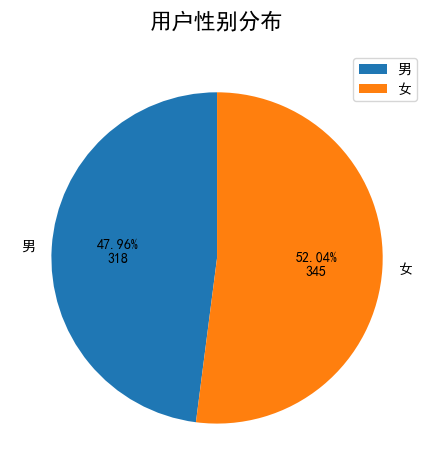

In [124]:
gender_user=df_merge.groupby(by='gender')['user_id'].count()
labels=['男','女']
values=np.array([gender_user['男'],gender_user['女']])
fig=plt.figure()
sub=fig.add_subplot(111)
sub.pie(values,labels=labels,startangle=90,autopct=lambda x:fraction(x,values))
sub.legend()
fig.suptitle('用户性别分布',fontsize=16)
fig.tight_layout()
plt.show()

In [125]:
gender_buy_mount=df_merge.groupby(by=['gender','category_1'])['buy_mount'].sum()
gender_buy_mount

gender  category_1
女       28            112
        38             94
        50008168      154
        50014815      303
        50022520       14
        122650008      23
男       28             81
        38             37
        50008168      158
        50014815       87
        50022520       14
        122650008      19
Name: buy_mount, dtype: int64

In [126]:
category_1_list=[28,38,50008168,50014815,50022520,122650008]

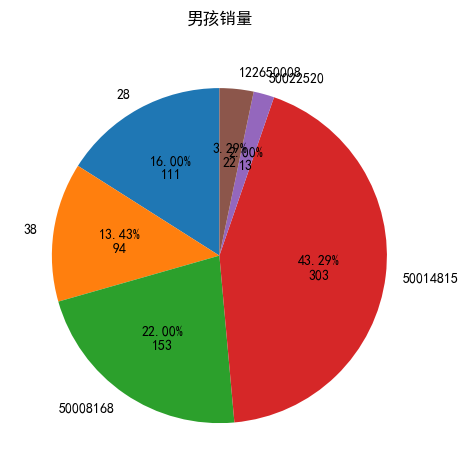

In [130]:
values=np.array([gender_buy_mount.loc['女',category] for category in category_1_list])
fig=plt.figure()
sub=fig.add_subplot(111)
sub.pie(values,labels=category_1_list,startangle=90,autopct=lambda x:fraction(x,values))
fig.suptitle('男孩销量')
fig.tight_layout()
plt.show()

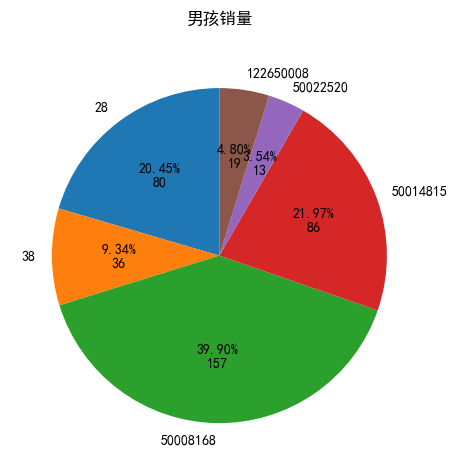

In [ ]:
values=np.array([gender_buy_mount.loc['男',category] for category in category_1_list])
fig=plt.figure()
sub=fig.add_subplot(111)
sub.pie(values,labels=category_1_list,startangle=90,autopct=lambda x:fraction(x,values))
fig.suptitle('女孩销量')
fig.tight_layout()
plt.show()